In [1]:
import os
os.chdir('..')

# Import Files

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn.hmm import GaussianHMM

from src.data_io import *
from src.realized_volatility import *
from src.mixture_autoregressive import *

In [3]:
symbol = 'SPY'
start_date = '2000-01-03'
end_date = '2025-12-31'

params = {
    'symbol': symbol,
    'start_date': start_date,
    'end_date': end_date,
    'interval': '1d'
}
yf = VolatilityYF(**params)
df = yf.pipeline()
df.columns.name = None
df.head(5)

[*********************100%***********************]  1 of 1 completed


,date,Adj Close,Close,High,Low,Open,Volume,log_return
0,2000-01-03,91.617058,145.4375,148.25000,143.875000,148.25000,8164300,NaN
1,2000-01-04,88.034286,139.7500,144.06250,139.640625,143.53125,8089800,-0.039891
2,2000-01-05,88.191734,140.0000,141.53125,137.250000,139.93750,12177900,0.001787
3,2000-01-06,86.774422,137.7500,141.50000,137.750000,139.62500,6227200,-0.016201
4,2000-01-07,91.813904,145.7500,145.75000,140.062500,140.31250,8066500,0.056452


In this project, we will model volatility instead of returns due to the usefulness of the clustering property. In this case, we will use the Garman-Klass volatility measure as a proxy for realized volatility:
$$GK_t = \sqrt{\frac{1}{2}\left[log\left(\frac{h_t}{l_t}\right)\right]^2 - (2log(2) - 1)\left[log\left(\frac{c_t}{o_t}\right)\right]^2}$$

In [4]:
realized_vol = df.loc[:, ['date']]
lfv = VolatilityMeasures(df)
realized_vol['realized_volatility'] = lfv.garman_klass_volatility(df['Close'], df['High'], df['Low'], df['Open'])

realized_vol.set_index('date', inplace=True)
realized_vol.index = pd.to_datetime(realized_vol.index, format='%Y-%m-%d')
realized_vol.head(5)

,realized_volatility
date,
2000-01-03,0.017520
2000-01-04,0.014512
2000-01-05,0.021718
2000-01-06,0.017032
2000-01-07,0.015289


In [5]:
train_df = realized_vol[realized_vol.index < '2020-01-01']
test_df = realized_vol[realized_vol.index >= '2020-01-01']
test_df.head(5)

,realized_volatility
date,
2020-01-02,0.004481
2020-01-03,0.005021
2020-01-06,0.004219
2020-01-07,0.002792
2020-01-08,0.006132


# MAR Fails to Capture Regimes

In [6]:
mar_grid_result = grid_search(data=train_df['realized_volatility'], max_components=3, max_ar=3, max_iter=500, seed=123)
mar_param = get_best_params(grid_result=mar_grid_result)
print(mar_param)

{'n_components': np.int64(3), 'phi_orders': (0, 1, 0)}


In [7]:
mar = OptimizedMAR(train_df['realized_volatility'], **mar_param, max_iter=500, seed=123)
mar.fit()
mar_result = {
    'log_likelihood': round(float(mar.log_likelihood), 4),
    'aic': round(float(mar.aic), 4),
    'bic': round(float(mar.bic), 4)
}
print(mar_result)

Parameters have converged.
{'log_likelihood': 25976.6022, 'aic': -51935.2043, 'bic': -51876.4957}


In [8]:
def plot_regime(df:pd.DataFrame, title:str='Volatility Regimes') -> plt.Figure:
    sns.scatterplot(data=df, x=df.index, y='realized_volatility', alpha=0.6, s=10, hue='cluster')
    plt.title(title)
    fig = plt.gcf()
    fig.set_size_inches(15, 5)
    return fig

Based on the chart, we note that the MAR model fails at capturing volatility regimes because its mixture components are not persistent latent states but instantaneous, observation-driven components. Moreover, volatility is not weakly stationary and hence results would be sub-optimal. As a result, MAR tends to cluster by level (e.g., low, medium, high volatility) rather than by regimes (perhaps more appropriate to say Stable, Transition and Anomalies as the levels). This lack of state persistence means MAR components can switch every period, which is not ideal for regimes.

Consequently, the proper use cases for MAR are not regime identification but short-horizon nonlinear forecasting, simulation and scenario generation. Moreover, the encoding of level information is useful as features. Instead of arbitrarily deciding on the range of values to cluster by level, we can use the MAR as a statistically-backed way to do so.

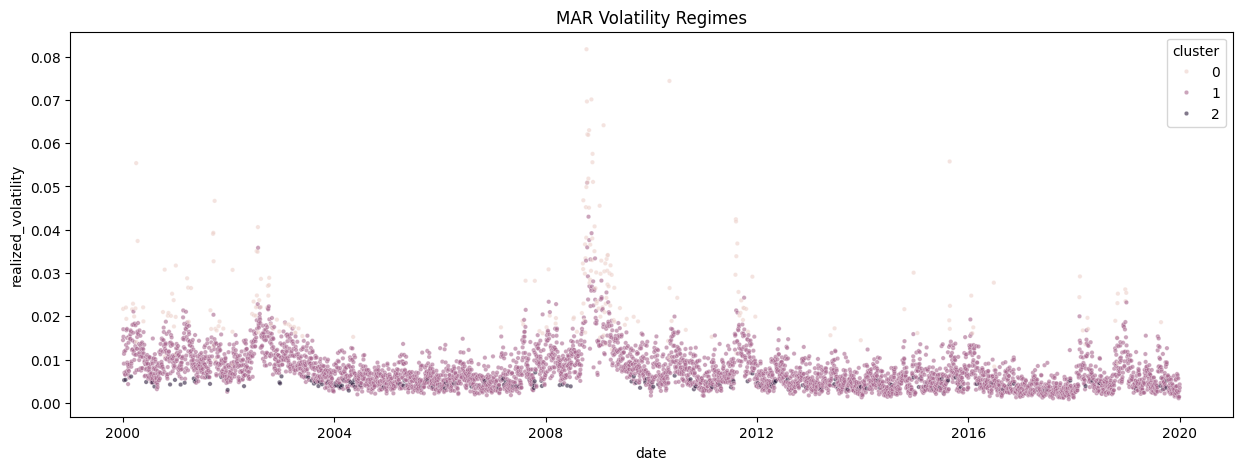

In [9]:
mar_df = train_df.copy()
mar_df['cluster'] = mar.greedy_assignment(mar.tau).to_numpy()
plot_regime(mar_df.iloc[1:], 'MAR Volatility Regimes') #We lose the first result
plt.show()

# Hidden Markov Model (HMM) 
The Markov property assumes that the future state depends only on the current state, not on the entire history. If one assumes that today's return $(R_t)$ contains all information up to that point $(\mathcal{F}_{t-1})$, then the Markov property should hold. This implies that we could use the HMM for regime classification.

A HMM is defined by $\lambda = (A, B, \pi)$, where $A$ is the transition matrix, $B$ is the emission matrix and $\pi$ is the initial state distribution.

Given our use case to identify market regimes, we have the following definitions:
- **States**: Regimes, such as high-volatility and low-volatility.
- **Observations**: Features, such as the components of HAR and the regime probabilities from MAR.
- **Transition Matrix**: Probabilities of switching between regimes.
- **Emission Matrix**: Probability distribution of observed features conditioned on the hidden state.

Source: https://www.geeksforgeeks.org/machine-learning/hidden-markov-model-in-machine-learning/

## Algorithm

The forward and backward algorithms are required to compute posterior regime probabilities in HMM, where regimes are hidden and only observations are known. Before we dive into the algorithm, note the following notations:
- **Hidden States** $S_t \in \{1,...,K\}$
- **Observations** $y_k$
- **Initial State Probabilities** $\pi_i = P(S_1 = i)$
- **Transition Probabilities** $P_{ij} = P(S_{t+1} = j | S_t = i)$
- **Transition Matrix** $P$
- **Emission Likelihoods** $f_i(y_t) = P(y_t | S_t = i)$
- **Emission Parameters** $\theta = (\mu_i, \Sigma_i)$

**Forward Algorithm** computes the probability of partial observations up to time t, for each possible hidden state $s_i$:
$$\alpha_t(i) = P(y_{1:t}, S_t = s_i | \lambda)$$

Below details the steps to calculate $\alpha_t(i)$:
1. Initialize $\alpha_1(i) = \pi_i \cdot f_i(y_1)$
2. Recursively calculate $\alpha_t(j) = \left(\sum^K_{i=1}\alpha_{t-1}(i) \cdot P_{ij}\right) \cdot f_j(y_t)$

**Backward Algorithm** computes the probability of future observations given current state $s_i$:
$$\beta_t(i) = P(y_{t+1:T} | S_t = s_i, \lambda)$$

Below details the steps to calculate $\beta_t(i)$:
1. Initialize $\beta_T(i) = 1$
2. Recursively calculate backwards $\beta_t(i) = \sum^K_{j=1}P_{ij} \cdot f_j(y_{t+1}) \cdot \beta_{t+1}(j)$

With $\alpha$ and $\beta$ calculated, we can calculate the posterior probability $P(S_t = i |y_{1:T})$:
$$\tau_t(i) = \frac{\alpha_t(i) \cdot \beta_t(i)}{\sum^K_{j=1}\alpha_t(j) \cdot \beta_t(j)}$$

Lastly, in order to update $P_{ij}$, we need Maximum Likelihood Estimation (MLE) through the Expectation-Maximization (EM) algorithm, specifically the **Baum-Welch** algorithm. Note that the following is assuming that observations follow a Gaussian distribution.

Steps:
1. Initialize all model parameters: (i) initial state distribution $\pi$, (ii) transition matrix $P$, emission parameters $\theta(\mu, \Sigma)$.

2. E-Step: Compute state posterior probability and transition posterior probability using forward-backward.
    - $\tau_t(i) = P(S_t = i | y_{1:T})$
    - $\zeta_t(i,j) = P(S_t = i, S_{t+1} = j | y_{1:T})$
$$\zeta_t(i,j) = \frac{\alpha_t(i) \cdot P_{ij} \cdot f_j(y_{t+1}) \cdot \beta_{t+1}(j)}{\sum^K_{a=1}\sum^K_{b=1}\alpha_t(a) \cdot P_{ab} \cdot f_b(y_{t+1}) \cdot \beta_{t+1}(b)}$$

3. M-Step: Update parameters:
$$\pi_i = \tau_1(i)$$
$$P_{ij} = \frac{\sum^{T-1}_{t=1} \zeta_t(i,j)}{\sum^{T-1}_{t=1} \tau_t(i)}$$
$$\mu_i = \frac{\sum^{T-1}_{t=1}\tau_t(i) \cdot y_t}{\sum^{T-1}_{t=1} \tau_t(i)}$$
$$\Sigma_i = \frac{\sum^{T-1}_{t=1}\tau_t(i) \cdot (y_t - \mu_i)(y_t - \mu_i)^T}{\sum^{T-1}_{t=1}\tau_t(i)}$$

Source: 
- https://github.com/romanmichaelpaolucci/Quant-Guild-Library/blob/main/2025%20Video%20Lectures/51.%20Hidden%20Markov%20Models%20for%20Quant%20Finance/hidden_markov_models.ipynb
- https://en.wikipedia.org/wiki/Baum%E2%80%93Welch_algorithm

Luckily, we do not have to implement the Gaussian HMM from scratch as there is a library. It was originally in sklearn, but has since been deprecated and moved to a seperate repository (hmmlearn).

# Gaussian HMM
## HAR-HMM

In this section, we will explore using features inspired by the Heterogeneous Autoregressive (HAR) model.

Since volatility is not stationary and taking the first-difference would remove the memory, we will use the log to stabilize the variance and bring the distribution closer to Gaussian.

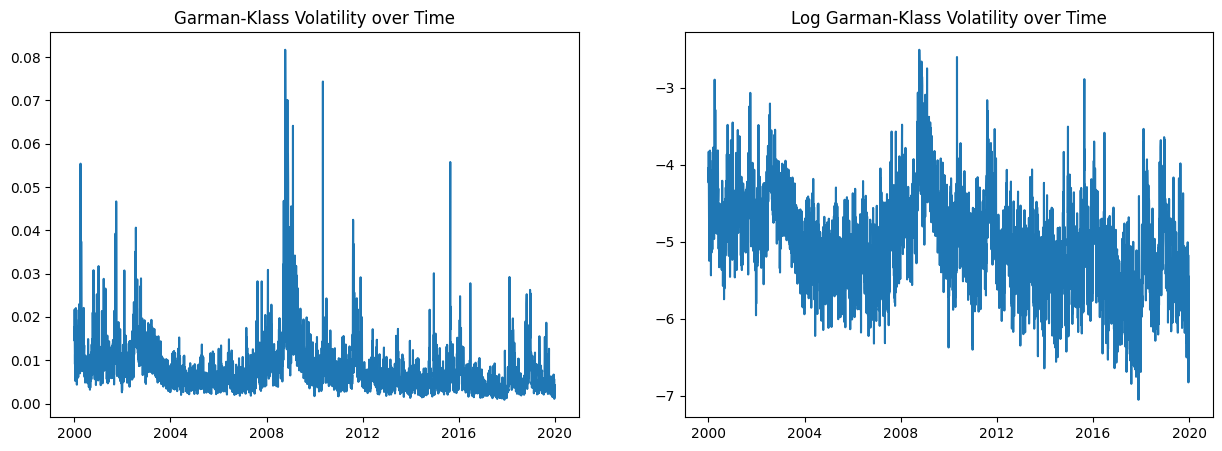

In [10]:
log_feature_df = train_df.copy()
log_feature_df['log_rv'] = np.log(log_feature_df['realized_volatility'])

fig, axes= plt.subplots(ncols=2, figsize=(15,5))
axes[0].plot(train_df)
axes[0].set_title("Garman-Klass Volatility over Time")
axes[1].plot(log_feature_df['log_rv'])
axes[1].set_title("Log Garman-Klass Volatility over Time")
plt.show()

We will also incorporate memory by using components from the HAR model.
$$GK_t = \beta_0 + \beta_1GK_{t-1} + \beta_2\frac{1}{W}\sum^W_{i=1}GK_{t-i} + \beta_3\frac{1}{M}\sum^M_{i=1}GK_{t-i} + \epsilon_t $$
where $W=5$ and $M=22$.

In our case, we want these two components:
- $\frac{1}{5}\sum^5_{i=1}GK_{t-i}$
- $\frac{1}{22}\sum^{22}_{i=1}GK_{t-i}$

We will fit one using the RV, and another one using log RV to observe whether the log-transform truly helps.

In [11]:
#Temporary function for convenience in this notebook
def fit_score_predict(df:pd.DataFrame, cov_type:str='full', n_components:int=3, n_iter:int=500, seed:int=123):
    X = df.to_numpy(dtype=float)
    model = GaussianHMM(n_components, cov_type, n_iter=n_iter, random_state=seed).fit(X)
    scores = {
        'log_likelihood': round(model.score(X), 4),
        'aic': round(model.aic(X), 4),
        'bic': round(float(model.bic(X)), 4)
    }
    predictions = model.predict(X)
    return model, scores, predictions

def har_features(df:pd.DataFrame, col_name:str='realized_volatility', short_window:int=5, long_window:int=22) -> pd.DataFrame:
    df = df.copy()
    df['weekly'] = df[col_name].rolling(short_window).mean()
    df['monthly'] = df[col_name].rolling(long_window).mean()
    df = df.dropna()
    return df

Based on the scores and the charts, we see that the model using log RV had a worse fit. The scores are self-explanatory with a significant difference. This is likely due to the log-domain removing key information from the observation. 

The logarithmic transformation disproportionately shrinks large volatility spikes and expands small fluctuations, this removes or compresses economically important information carried by volatility levels and extreme events. Thus, while the log domain improves statistical properties, the trade-off (loss of critical information) is not justified. We are likely modelling levels instead of regimes.

{'log_likelihood': 71955.4526, 'aic': -143840.9051, 'bic': -143612.7334}


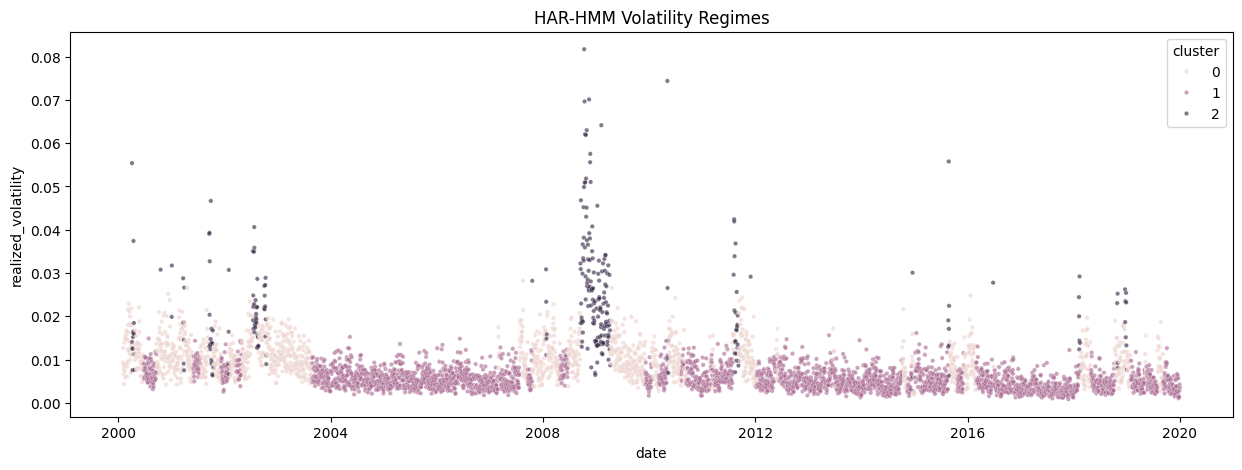

In [12]:
feature_df = train_df.copy()
feature_df = har_features(feature_df)

model_one, model_one_scores, preds = fit_score_predict(feature_df)
model_one_df = feature_df.copy()
model_one_df['cluster'] = preds

print(model_one_scores)
plot_regime(model_one_df, 'HAR-HMM Volatility Regimes')
plt.show()

{'log_likelihood': -567.372, 'aic': 1204.7441, 'bic': 1432.9158}


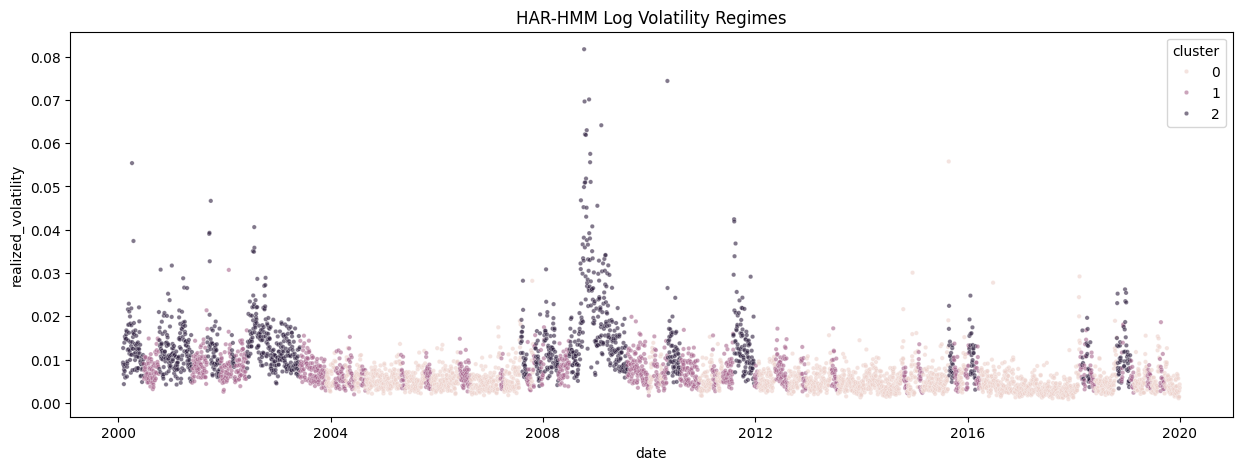

In [13]:
log_feature_df = har_features(log_feature_df, 'log_rv')
model_two, model_two_scores, preds = fit_score_predict(log_feature_df.iloc[:, 1:])
model_two_df = log_feature_df.copy()
model_two_df['cluster'] = preds

print(model_two_scores)
plot_regime(model_two_df, 'HAR-HMM Log Volatility Regimes')
plt.show()

Now, we shall observe the non-logged model's effectiveness on out-of-sample data. Of which, it seems to have captured the spike in volatility during the COVID19 period. Below are the regime classifications:
- Cluster 0: Transition
- Cluster 1: Stable
- Cluster 2: Stress

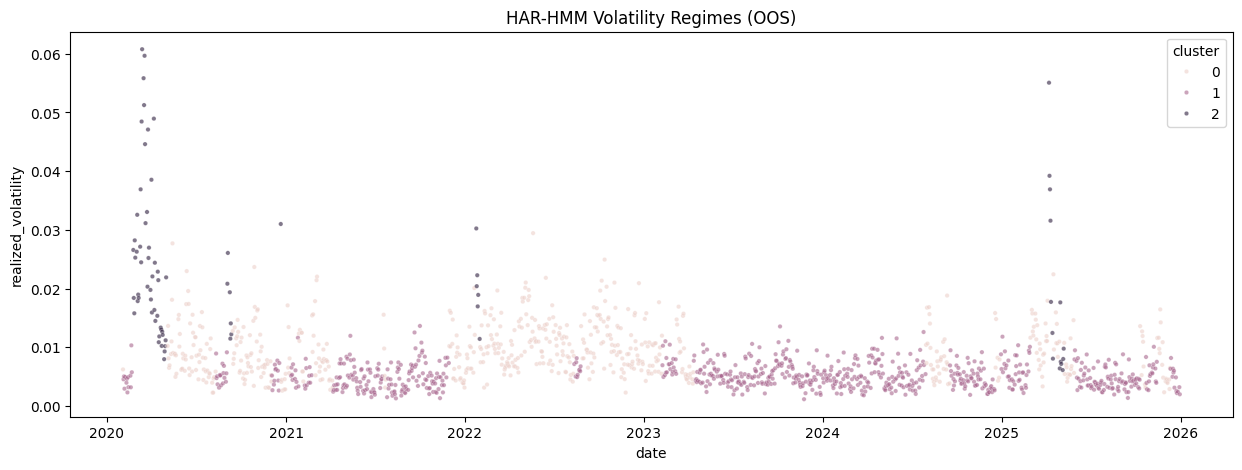

In [14]:
model_one_oos = har_features(test_df.copy())
model_one_oos['cluster'] = model_one.predict(model_one_oos.to_numpy(dtype=float))
plot_regime(model_one_oos, 'HAR-HMM Volatility Regimes (OOS)')
plt.show()

## Mixture Weighted MAR-HMM

In order to encode level and ex-ante structural uncertainty under regime ambiguity information, we will use the conditional mean and conditional variance respectively:
$$E[y_t | \mathcal{F_{t-1}}] = \sum^K_{k=1}\alpha_k\mu_{k,t}$$
$$V[y_t | \mathcal{F_{t-1}}] = \sum^K_{k=1}\alpha_k\sigma^2_k + \sum^K_{k=1}\alpha_k\mu^2_{k,t} - \left(\sum^K_{k=1}\alpha_k\mu_{k,t}\right)^2$$
where $\alpha_k$ is the mixture weight, $\sigma^2_k$ is the variance of individual Gaussian distributions, $\mu_{k,t}$ is the time-varying mean of individual Gaussian distributions.

**Conditional Mean**: We can infer from the equation that it encodes level information as a mixture-weighted sum of means of all components. Therefore, we are assuming that volatility is a mixture of Autoregressive Gaussian Distributions with fixed contributions. Of course, this might not necessarily be true as one could argue that the contributions should be time-varying, assuming that each component models different levels of risk or perhaps investors' sentiments. 

However, since we already use the actual observation as a feature, the level information is already encoded. In order to avoid overlapping information, we can use the residual between the actual observation and the regime-expected behaviour. This deviation should encode information on the surprise.

**Conditional Variance**: We can infer from the equation that it encodes structural uncertainty as a mixture-weighted sum of within-regime uncertainty and between-regime uncertainty. Once again, the assumes fixed contributions, which might not be true. This can be seen if we rewrite the equation to the following:
$$V[y_t | \mathcal{F_{t-1}}] = \sum^K_{k=1}\alpha_k\left[\sigma^2_k + \left(\mu^2_{k,t} - \bar{\mu}_t\right)^2\right]$$
where $\sigma^2_k$ is the noise inherent to each regime and $(\mu^2_{k,t} - \bar{\mu}_t)^2$ is the dispersion across regime-specific conditional means.

Note the following equation that was used to calculate $\epsilon$:
$$\epsilon_{k,t} = y_t - \mu_{k,t}$$
$$\mu_{k,t} = y_t - \epsilon_{k,t}$$

In [15]:
def calc_conditional_mean(weights:np.ndarray, y:np.ndarray, epsilon:np.ndarray) -> np.ndarray:
    mu = y - epsilon #(t, k)
    if weights.ndim == 1:
        return  mu@weights
    
    return np.sum(weights*mu, axis=1)

calc_conditional_mean(mar.params['alpha'], train_df[1:].to_numpy(), mar.epsilon[1:])

array([0.01269067, 0.01124888, 0.01470339, ..., 0.00498165, 0.00566507,
       0.00634605], shape=(5030,))

In [16]:
def calc_conditional_var(weights:np.ndarray, sigma:np.ndarray, y:np.ndarray, epsilon:np.ndarray) -> np.ndarray:
     mu = y - epsilon #(t, k)
     mu_squared = mu**2 #(t,k)
     variance = sigma**2 #(k, )
     
     if weights.ndim == 1:
          return variance@weights + mu_squared@weights - (mu@weights)**2
     
     return weights@variance + np.sum(weights*mu_squared, axis=1) - np.sum(weights*mu, axis=1)**2

calc_conditional_var(mar.params['alpha'], mar.params['sigma'], train_df[1:].to_numpy(), mar.epsilon[1:])

array([3.25228418e-05, 3.05786753e-05, 3.70525545e-05, ...,
       3.47445923e-05, 3.32937837e-05, 3.20907664e-05], shape=(5030,))

To ensure that the features are on the same scale (%), we will take the square root of the conditional variance to get the conditional standard deviation.

In [30]:
def mar_features(df:pd.DataFrame, weights:np.ndarray, sigma:np.ndarray, epsilon:np.ndarray, keep_cond_mean:bool=False) -> pd.DataFrame:
    df = df.copy()
    mu = calc_conditional_mean(weights, df[1:].to_numpy(), epsilon[1:])
    var = calc_conditional_var(weights, sigma, df[1:].to_numpy(), epsilon[1:])

    df = df.iloc[1:]
    if keep_cond_mean:
        df['conditional_mu'] = mu
    
    df['excess_resid'] = df['realized_volatility'] - mu
    df['conditional_std'] = np.sqrt(var)
    df = df.dropna()
    return df

Based on the results, we observe that the regime classifications are less reactive. Below are the regime classifications:
- Cluster 0: Stable
- Cluster 1: Uncertain
- Cluster 2: Stress

We achieve longer stretches for the Stable regime, but we also observe that the Uncertain and Stress periods tend to switch often. Perhaps, it would be better to treat the Uncertain and Stress regime as the same to be prudent, espeically when dealing with volatility where we would prefer to overestimate than to underestimate volatility.

{'log_likelihood': 73628.1263, 'aic': -147186.2526, 'bic': -146957.9415}


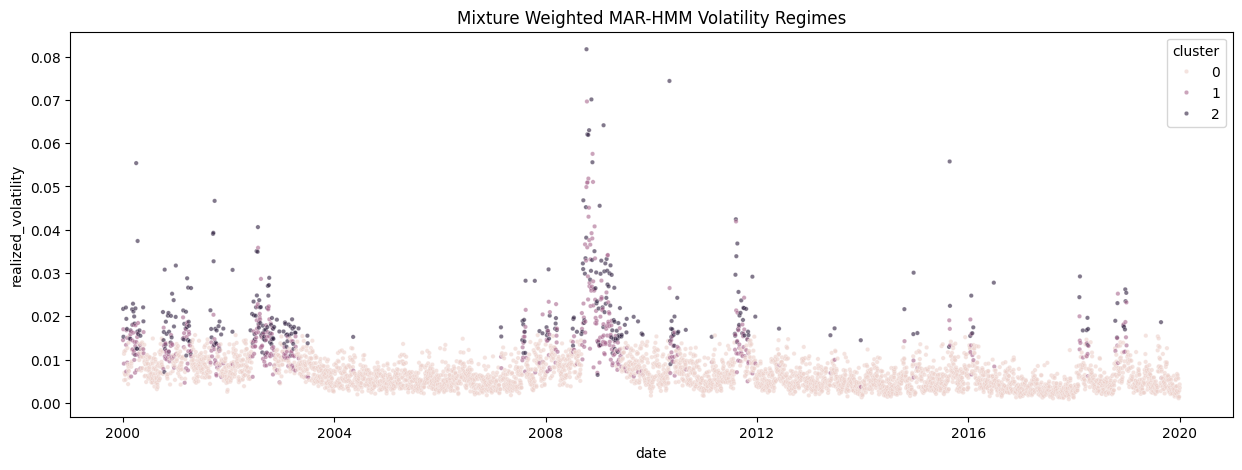

In [18]:
feature_df = mar_features(train_df.copy(), mar.params['alpha'], mar.params['sigma'], mar.epsilon)
alpha_model, alpha_model_scores, preds = fit_score_predict(feature_df)
alpha_model_df = feature_df.copy()
alpha_model_df['cluster'] = preds

print(alpha_model_scores)
plot_regime(alpha_model_df, 'Mixture Weighted MAR-HMM Volatility Regimes')
plt.show()

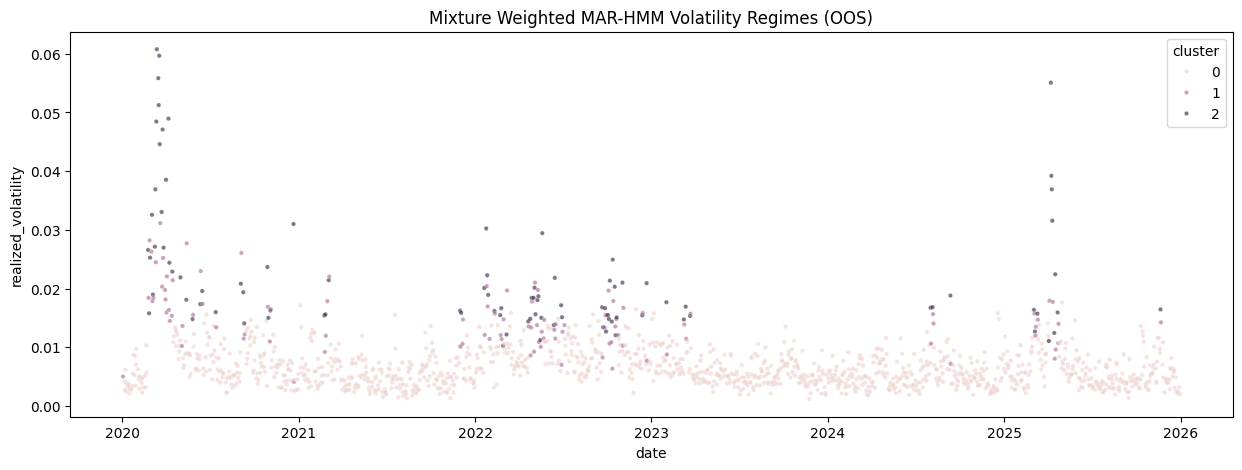

In [19]:
eps, tau = mar.predict(test_df.to_numpy(dtype=float))
alpha_model_oos = mar_features(test_df.copy(), mar.params['alpha'], mar.params['sigma'], eps)
alpha_model_oos['cluster'] = alpha_model.predict(alpha_model_oos.to_numpy(dtype=float))
plot_regime(alpha_model_oos, 'Mixture Weighted MAR-HMM Volatility Regimes (OOS)')
plt.show()

## Posterior Probability Weighted MAR-HMM

Alternatively, we could use the posterior probability instead of the mixture weight.
$$\tau_{k,t} = \frac{(\alpha_k/\sigma_k)\phi(\epsilon_{k,t}/\sigma_k)}{\sum^K_{k=1}(\alpha_k/\sigma_k)\phi(\epsilon_{k,t}/\sigma_k)}$$

Note that this would change the definition of the information we are encoding:
$$E[y_t | \mathcal{F_{t-1}}] = \sum^K_{k=1}\tau_k\mu_{k,t}$$
$$V[y_t | \mathcal{F_{t-1}}] = \sum^K_{k=1}\tau_k\sigma^2_k + \sum^K_{k=1}\tau_k\mu^2_{k,t} - \left(\sum^K_{k=1}\tau_k\mu_{k,t}\right)^2$$

**Conditional Mean**: Incorporates uncertainty about component membership rather than relying on fixed mixture contributions. As a result, the posterior-weighted conditional mean adapts to changes in the likelihood of each component, capturing time-varying dominance of different autoregressive structures. Again, since this still captures level information, we will use the residuals to encode surprise.

**Conditional Variance**: This quantity reflects how well each component explains the current observation, thereby emphasizing uncertainty associated with the most likely component configurations at a given point in time. Note that this means that the final model will be observation-aware and adapts rapidly to changes in market conditions, which implies a more reactive model.

Note that the model is not converging as the Expectation-Maximization algorithm expects log-likelihood to be monotonically increasing. In our case, the log-likelihood dropped by -0.01. Nonetheless, this is a tiny dip and the regime clusters look reasonable, hence we can move forward.

Model is not converging.  Current: 74606.36677699021 is not greater than 74606.37732942558. Delta is -0.010552435371209867


{'log_likelihood': 74606.3321, 'aic': -149142.6641, 'bic': -148914.353}


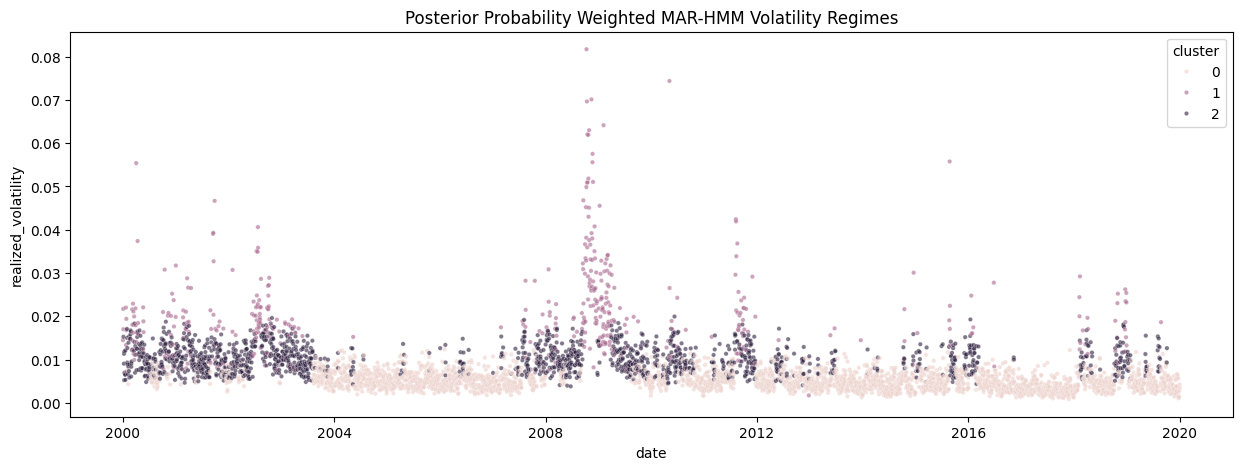

In [24]:
feature_df = mar_features(train_df.copy(), mar.tau[1:], mar.params['sigma'], mar.epsilon)
tau_model, tau_model_scores, preds = fit_score_predict(feature_df, n_components=3)
tau_model_df = feature_df.copy()
tau_model_df['cluster'] = preds

print(tau_model_scores)
plot_regime(tau_model_df, 'Posterior Probability Weighted MAR-HMM Volatility Regimes')
plt.show()

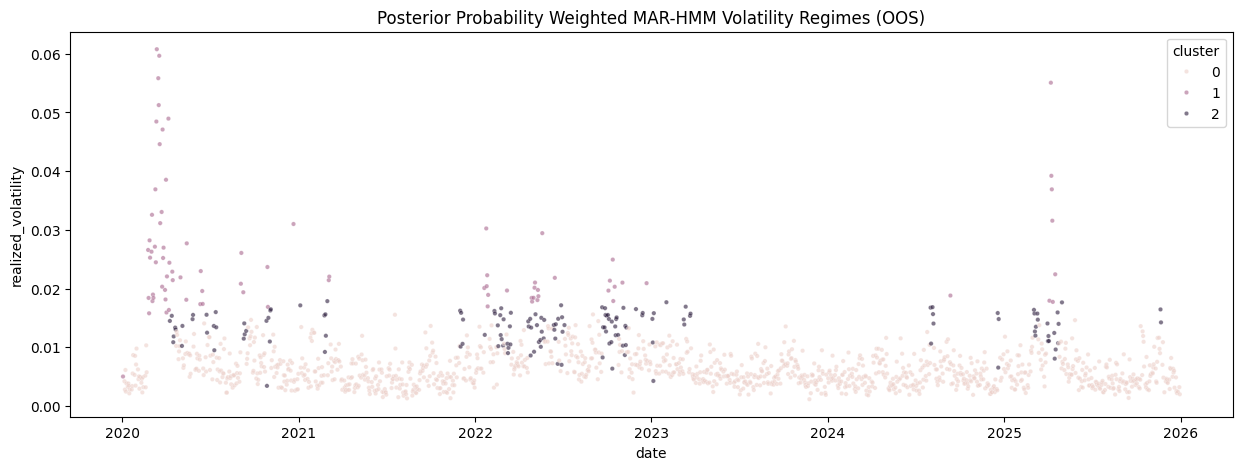

In [25]:
eps, tau = mar.predict(test_df.to_numpy(dtype=float))
tau_model_oos = mar_features(test_df.copy(), mar.params['alpha'], mar.params['sigma'], eps)
tau_model_oos['cluster'] = tau_model.predict(tau_model_oos.to_numpy(dtype=float))
plot_regime(tau_model_oos, 'Posterior Probability Weighted MAR-HMM Volatility Regimes (OOS)')
plt.show()

## Gap-Based MAR-HMM

{'log_likelihood': 139097.5563, 'aic': -278059.1126, 'bic': -277615.5367}


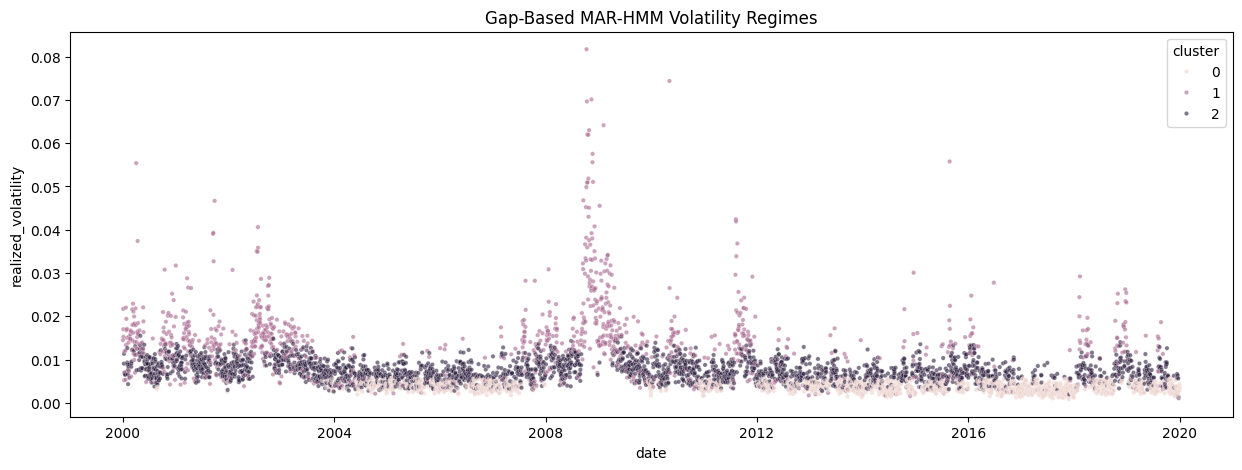

In [36]:
tmp1 = mar_features(train_df.copy(), mar.params['alpha'], mar.params['sigma'], mar.epsilon, keep_cond_mean=True)
tmp2 = mar_features(train_df.copy(), mar.tau[1:], mar.params['sigma'], mar.epsilon, keep_cond_mean=True)
feature_df = train_df.copy().iloc[1:]
feature_df['conditional_mu'] = tmp1['conditional_mu']
feature_df['condtional_std'] = tmp1['conditional_std']
feature_df['level_gap'] = tmp2['conditional_mu'] - tmp1['conditional_mu']
feature_df['uncertainty_gap'] = tmp2['conditional_std'] - tmp1['conditional_std']
gap_based_model, gap_based_model_scores, preds = fit_score_predict(feature_df)
gap_based_model_df = feature_df.copy()
gap_based_model_df['cluster'] = preds

print(gap_based_model_scores)
plot_regime(gap_based_model_df, 'Gap-Based MAR-HMM Volatility Regimes')
plt.show()

# Performance Measures

Now that we have our candidate models, we need to compare them. The issue with the log-likelihood and BIC is that, it only looks at the model fit. This is an issue as even though a model has the "best-fit", regime classification is subjective to the user's purpose. Hence, a model with a "bad-fit" could still provide the highest utility.

